# 轻量基线模型训练（价格预测）

本 notebook 完整实现以下流程：

1. 数据管道：从 `data/processed/` 加载 1min CSV → 特征工程 → 价格标签 → 滑动窗口序列
2. 模型训练：LightGBM / XGBoost（表格模型）、LSTM / TCN（时序模型）
3. 评估与对比：RMSE / MAE / R² / 方向准确率 / 训练时间 / 推理时间
4. 可视化：预测 vs 真实曲线、对比表

| 模型 | 输入格式 | 说明 |
|------|----------|------|
| LightGBM | `X_flat` (N, lookback×F) | 树模型，表格特征 |
| XGBoost | `X_flat` (N, lookback×F) | 树模型，表格特征 |
| LSTM | `X_seq` (N, lookback, F) | 两层轻量 LSTM |
| TCN | `X_seq` (N, lookback, F) | 轻量时序卷积网络 |

预测目标：未来 30 分钟的 `mid_price`（回归）。

## 1. 导入与数据管道

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import time
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


class LOBDataPipeline:
    """统一数据管道（价格预测）"""

    def __init__(self, data_dir, lookback=60, horizon=30):
        self.data_dir = Path(data_dir)
        self.lookback = lookback
        self.horizon = horizon

    def load_raw(self, ticker):
        df = pd.read_csv(self.data_dir / f"{ticker}_1min.csv", parse_dates=["timestamp"])
        df = df.set_index("timestamp").sort_index()
        df = df.between_time("09:45", "15:45")
        return df

    def engineer_features(self, df):
        df["mid_price"] = (df["best_ask"] + df["best_bid"]) / 2
        df["spread"] = df["best_ask"] - df["best_bid"]
        denom = df["bid_size"] + df["ask_size"]
        df["order_imbalance"] = np.where(denom != 0, (df["bid_size"] - df["ask_size"]) / denom, 0)
        df["log_return"] = np.log(df["mid_price"]).diff()
        for w in [5, 10, 20]:
            df[f"vol_{w}"] = df["log_return"].rolling(w).std()
        for w in [5, 10, 20]:
            df[f"vol_ma_{w}"] = df["trade_volume"].rolling(w).mean()
        df["vol_spike"] = np.where(df["vol_ma_20"] != 0, df["trade_volume"] / df["vol_ma_20"], 0)
        for feat in ["spread", "order_imbalance", "log_return", "trade_volume"]:
            for lag in [1, 5, 10, 20]:
                df[f"{feat}_lag{lag}"] = df[feat].shift(lag)
        return df.dropna()

    def build_price_labels(self, df):
        df = df.copy()
        df["target_price"] = df["mid_price"].shift(-self.horizon)
        return df.iloc[:-self.horizon]

    def build_sequences(self, df, feature_cols, target_col="target_price"):
        X_list, y_list = [], []
        values = df[feature_cols].values
        labels = df[target_col].values
        for i in range(self.lookback, len(df)):
            X_list.append(values[i - self.lookback: i])
            y_list.append(labels[i])
        X_seq = np.array(X_list)
        X_flat = X_seq.reshape(len(X_seq), -1)
        y = np.array(y_list)
        return X_seq, X_flat, y


def evaluate(y_true, y_pred, y_current):
    """回归评估：RMSE / MAE / R² / 方向准确率"""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    true_dir = np.sign(y_true - y_current)
    pred_dir = np.sign(y_pred - y_current)
    dir_acc = np.mean(true_dir == pred_dir)
    return {"RMSE": rmse, "MAE": mae, "R2": r2, "DirAcc": dir_acc}


print("数据管道与评估函数已定义。")

数据管道与评估函数已定义。


## 2. 配置与数据加载

In [2]:
# ====== 配置 ======
DATA_DIR    = "../data/processed"    # 相对于 baselines/ 目录
LOOKBACK    = 60
HORIZON     = 30
TRAIN_RATIO = 0.8

FEATURE_COLS = [
    "mid_price", "spread", "order_imbalance", "log_return",
    "vol_5", "vol_10", "vol_20",
    "vol_ma_5", "vol_ma_10", "vol_ma_20", "vol_spike",
]

# 获取全部股票列表
tickers = sorted([
    f.stem.replace("_1min", "")
    for f in Path(DATA_DIR).glob("*_1min.csv")
    if " " not in f.stem
])
print(f"共 {len(tickers)} 只股票: {tickers}")

共 15 只股票: ['1319', '1401', '1405', '1419', '1518', '1712', '1722', '1743', '1766', '1780', '1801', '1802', '1803', '1812', '1840']


## 3. LightGBM 与 XGBoost 训练

In [3]:
import lightgbm as lgb
import xgboost as xgb

pipeline = LOBDataPipeline(data_dir=DATA_DIR, lookback=LOOKBACK, horizon=HORIZON)
all_results = []
best_preds = {}  # 存储最佳股票的预测结果用于可视化

for ticker in tickers:
    # 数据准备
    df_raw = pipeline.load_raw(ticker)
    df_feat = pipeline.engineer_features(df_raw)
    df_labeled = pipeline.build_price_labels(df_feat)
    feat_cols = [c for c in FEATURE_COLS if c in df_labeled.columns]
    X_seq, X_flat, y = pipeline.build_sequences(df_labeled, feat_cols)

    if len(y) < 200:
        print(f"  {ticker}: 跳过（样本 {len(y)} 太少）")
        continue

    # 按时间 80/20 切分
    split = int(len(y) * TRAIN_RATIO)
    X_train, X_test = X_flat[:split], X_flat[split:]
    y_train, y_test = y[:split], y[split:]
    mid_idx = feat_cols.index("mid_price")
    y_current_test = X_seq[split:, -1, mid_idx]

    # ---------- LightGBM ----------
    lgbm_model = lgb.LGBMRegressor(
        objective="regression", metric="rmse", verbosity=-1,
        num_leaves=63, learning_rate=0.05, n_estimators=500,
    )
    t0 = time.time()
    lgbm_model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        callbacks=[lgb.early_stopping(50, verbose=False)],
    )
    lgbm_train_t = time.time() - t0

    t0 = time.time()
    y_pred_lgbm = lgbm_model.predict(X_test)
    lgbm_infer_t = time.time() - t0

    m = evaluate(y_test, y_pred_lgbm, y_current_test)
    m.update({"ticker": ticker, "model": "LightGBM", "train_s": lgbm_train_t, "infer_s": lgbm_infer_t})
    all_results.append(m)

    # ---------- XGBoost ----------
    xgb_model = xgb.XGBRegressor(
        objective="reg:squarederror", eval_metric="rmse", verbosity=0,
        max_depth=6, learning_rate=0.05, n_estimators=500,
        early_stopping_rounds=50,
    )
    t0 = time.time()
    xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    xgb_train_t = time.time() - t0

    t0 = time.time()
    y_pred_xgb = xgb_model.predict(X_test)
    xgb_infer_t = time.time() - t0

    m = evaluate(y_test, y_pred_xgb, y_current_test)
    m.update({"ticker": ticker, "model": "XGBoost", "train_s": xgb_train_t, "infer_s": xgb_infer_t})
    all_results.append(m)

    # 保存预测用于可视化
    best_preds[ticker] = {
        "y_test": y_test, "y_current": y_current_test,
        "lgbm": y_pred_lgbm, "xgb": y_pred_xgb,
    }

    r_lg = all_results[-2]
    r_xg = all_results[-1]
    print(f"  {ticker}: LGBM R²={r_lg['R2']:.4f} DA={r_lg['DirAcc']:.4f} | XGB R²={r_xg['R2']:.4f} DA={r_xg['DirAcc']:.4f}")

print(f"\n训练完成，共 {len(all_results)} 条结果。")

  1319: LGBM R²=0.7141 DA=0.2170 | XGB R²=0.7446 DA=0.2214
  1401: LGBM R²=-0.3082 DA=0.2995 | XGB R²=-0.4365 DA=0.2679
  1405: LGBM R²=-0.7518 DA=0.5136 | XGB R²=-1.6371 DA=0.1682
  1419: LGBM R²=0.0210 DA=0.6023 | XGB R²=0.4551 DA=0.6023
  1518: LGBM R²=0.4377 DA=0.1532 | XGB R²=0.5804 DA=0.1486
  1712: LGBM R²=-0.3230 DA=0.3573 | XGB R²=-0.3196 DA=0.3532
  1722: LGBM R²=0.8062 DA=0.5662 | XGB R²=0.8481 DA=0.5084
  1743: LGBM R²=0.3354 DA=0.1479 | XGB R²=0.2314 DA=0.1667
  1766: LGBM R²=0.4468 DA=0.4198 | XGB R²=0.4390 DA=0.4226
  1780: LGBM R²=-1.6228 DA=0.4974 | XGB R²=-1.9279 DA=0.4603
  1801: LGBM R²=-0.3922 DA=0.4292 | XGB R²=-0.7199 DA=0.4125
  1802: LGBM R²=0.7209 DA=0.7194 | XGB R²=0.7290 DA=0.6861
  1803: LGBM R²=0.6585 DA=0.5277 | XGB R²=0.6752 DA=0.5034
  1812: LGBM R²=0.2579 DA=0.5586 | XGB R²=0.4719 DA=0.5601
  1840: LGBM R²=-0.9856 DA=0.4853 | XGB R²=-0.7590 DA=0.4343

训练完成，共 30 条结果。


## 4. 对比表

In [4]:
df_res = pd.DataFrame(all_results)
col_order = ["ticker", "model", "RMSE", "MAE", "R2", "DirAcc", "train_s", "infer_s"]
df_res = df_res[col_order]
for col in ["RMSE", "MAE", "R2", "DirAcc", "train_s", "infer_s"]:
    df_res[col] = df_res[col].round(4)

print("=" * 90)
print("  LightGBM vs XGBoost 全部股票逐只对比")
print("=" * 90)
print(df_res.to_string(index=False))

print("\n--- 按模型汇总（均值） ---")
summary = df_res.groupby("model")[["RMSE", "MAE", "R2", "DirAcc", "train_s", "infer_s"]].mean().round(4)
print(summary.to_string())

  LightGBM vs XGBoost 全部股票逐只对比
ticker    model     RMSE      MAE      R2  DirAcc  train_s  infer_s
  1319 LightGBM   2.9917   2.2493  0.7141  0.2170   3.3485   0.0029
  1319  XGBoost   2.8272   2.0074  0.7446  0.2214   0.6208   0.0012
  1401 LightGBM  27.5495  20.0424 -0.3082  0.2995   2.5530   0.0020
  1401  XGBoost  28.8693  20.8547 -0.4365  0.2679   1.1674   0.0008
  1405 LightGBM   4.1500   2.1084 -0.7518  0.5136   0.3885   0.0008
  1405  XGBoost   5.0918   3.5138 -1.6371  0.1682   0.3914   0.0005
  1419 LightGBM   4.4774   4.0540  0.0210  0.6023   0.9731   0.0009
  1419  XGBoost   3.3402   2.5211  0.4551  0.6023   0.6697   0.0005
  1518 LightGBM   1.0911   0.9152  0.4377  0.1532   2.1485   0.0014
  1518  XGBoost   0.9425   0.7764  0.5804  0.1486   0.9355   0.0005
  1712 LightGBM  16.9704  14.3802 -0.3230  0.3573   4.0447   0.0031
  1712  XGBoost  16.9488  14.2356 -0.3196  0.3532   2.5049   0.0017
  1722 LightGBM   9.7203   7.9443  0.8062  0.5662   1.5053   0.0010
  1722  XGBoost  

## 5. 可视化：预测 vs 真实价格

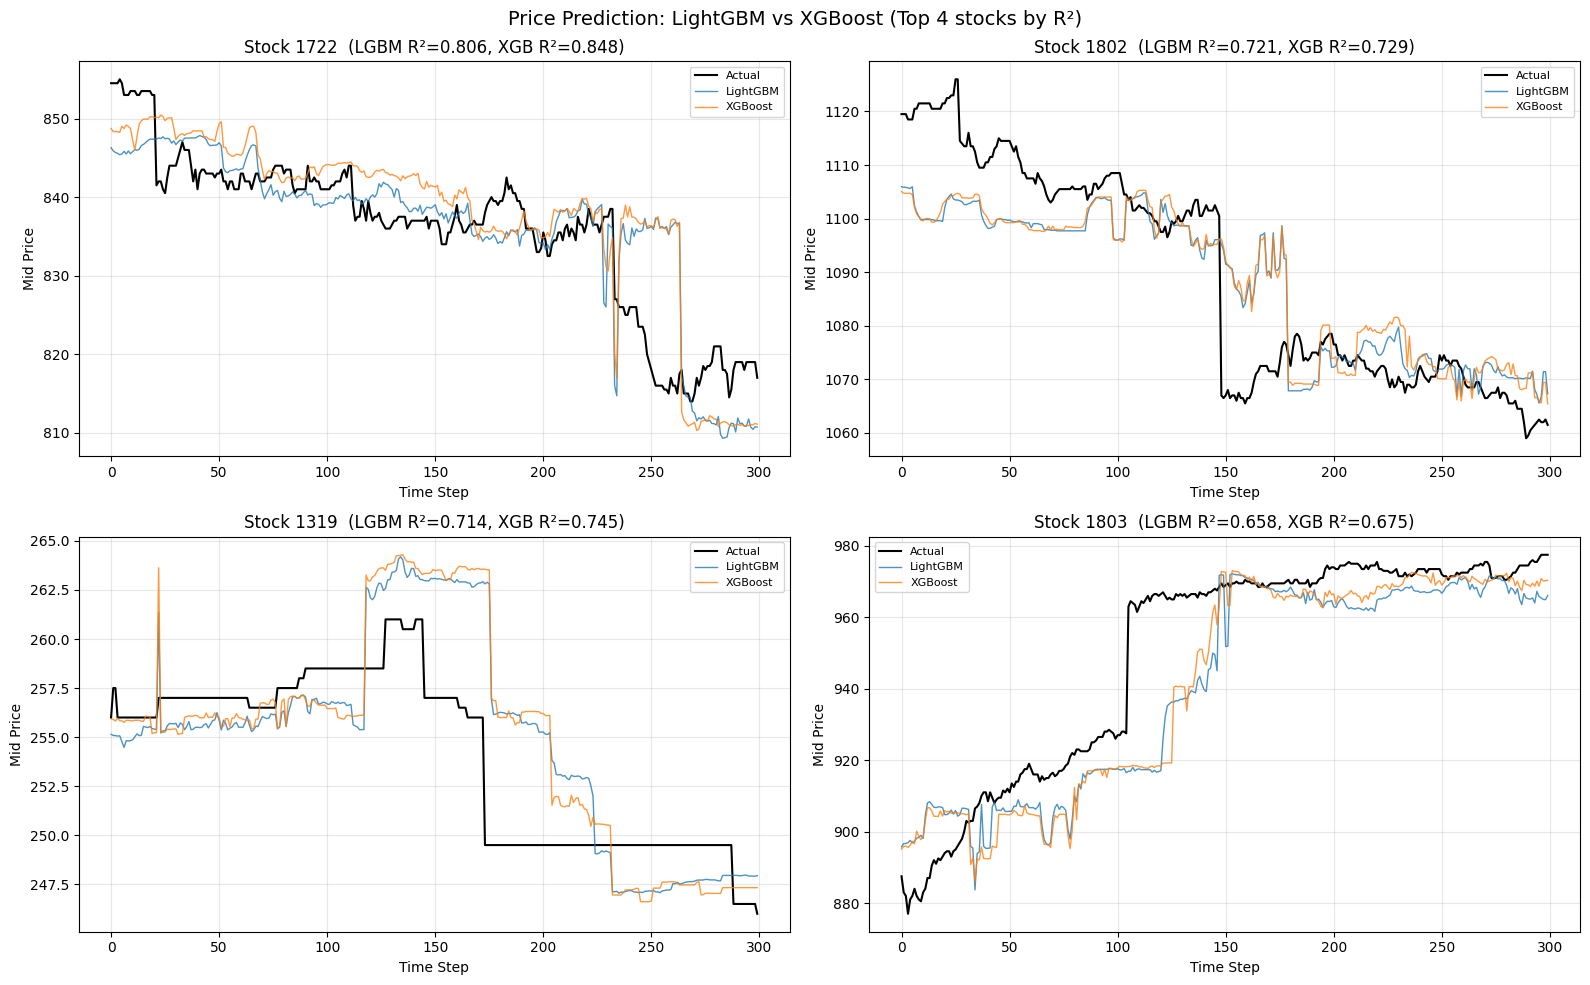

图表已保存为 baselines/lgbm_xgb_prediction.png


In [5]:
# 选取 R² 最高的 4 只股票做可视化
df_lgbm = df_res[df_res["model"] == "LightGBM"].sort_values("R2", ascending=False)
top_tickers = df_lgbm["ticker"].head(4).tolist()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Price Prediction: LightGBM vs XGBoost (Top 4 stocks by R²)", fontsize=14)

for ax, ticker in zip(axes.flat, top_tickers):
    p = best_preds[ticker]
    n_show = min(300, len(p["y_test"]))  # 显示前 300 个时间步

    ax.plot(p["y_test"][:n_show], label="Actual", color="black", linewidth=1.5)
    ax.plot(p["lgbm"][:n_show], label="LightGBM", color="#1f77b4", linewidth=1, alpha=0.8)
    ax.plot(p["xgb"][:n_show], label="XGBoost", color="#ff7f0e", linewidth=1, alpha=0.8)

    r2_lg = df_res[(df_res["ticker"] == ticker) & (df_res["model"] == "LightGBM")]["R2"].values[0]
    r2_xg = df_res[(df_res["ticker"] == ticker) & (df_res["model"] == "XGBoost")]["R2"].values[0]
    ax.set_title(f"Stock {ticker}  (LGBM R²={r2_lg:.3f}, XGB R²={r2_xg:.3f})")
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Mid Price")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("lgbm_xgb_prediction.png", dpi=150, bbox_inches="tight")
plt.show()
print("图表已保存为 baselines/lgbm_xgb_prediction.png")

## 6. 可视化：模型 R² 对比（所有股票）

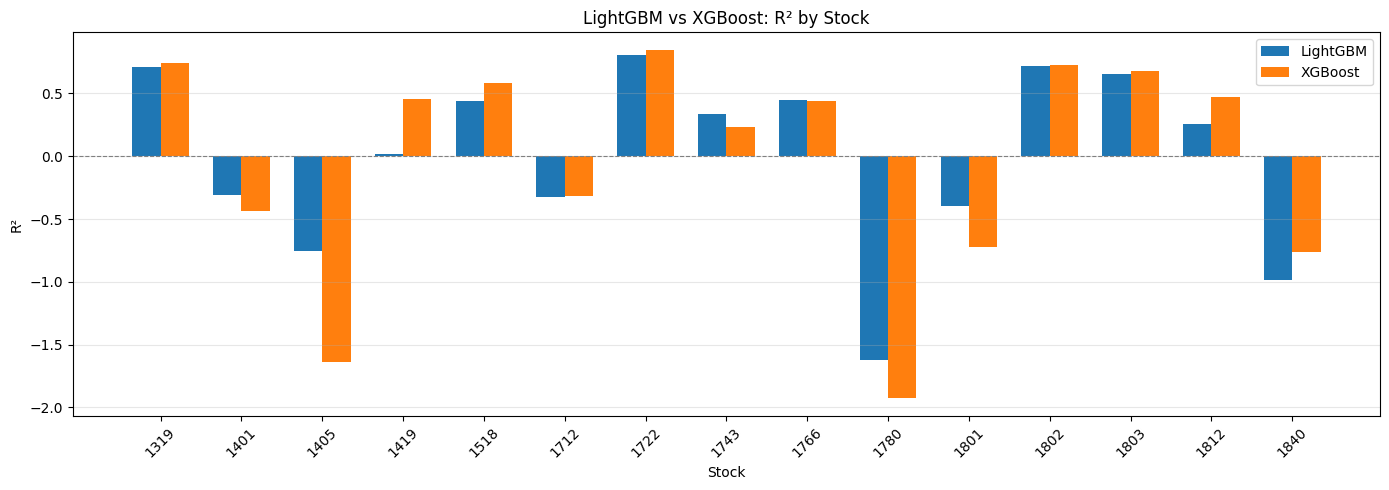

图表已保存为 baselines/lgbm_xgb_r2_comparison.png


In [6]:
# R² 柱状图
pivot = df_res.pivot(index="ticker", columns="model", values="R2")

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(pivot))
width = 0.35

bars1 = ax.bar(x - width/2, pivot["LightGBM"], width, label="LightGBM", color="#1f77b4")
bars2 = ax.bar(x + width/2, pivot["XGBoost"], width, label="XGBoost", color="#ff7f0e")

ax.axhline(y=0, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("Stock")
ax.set_ylabel("R²")
ax.set_title("LightGBM vs XGBoost: R² by Stock")
ax.set_xticks(x)
ax.set_xticklabels(pivot.index, rotation=45)
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("lgbm_xgb_r2_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("图表已保存为 baselines/lgbm_xgb_r2_comparison.png")

## 7. 可视化：方向准确率对比

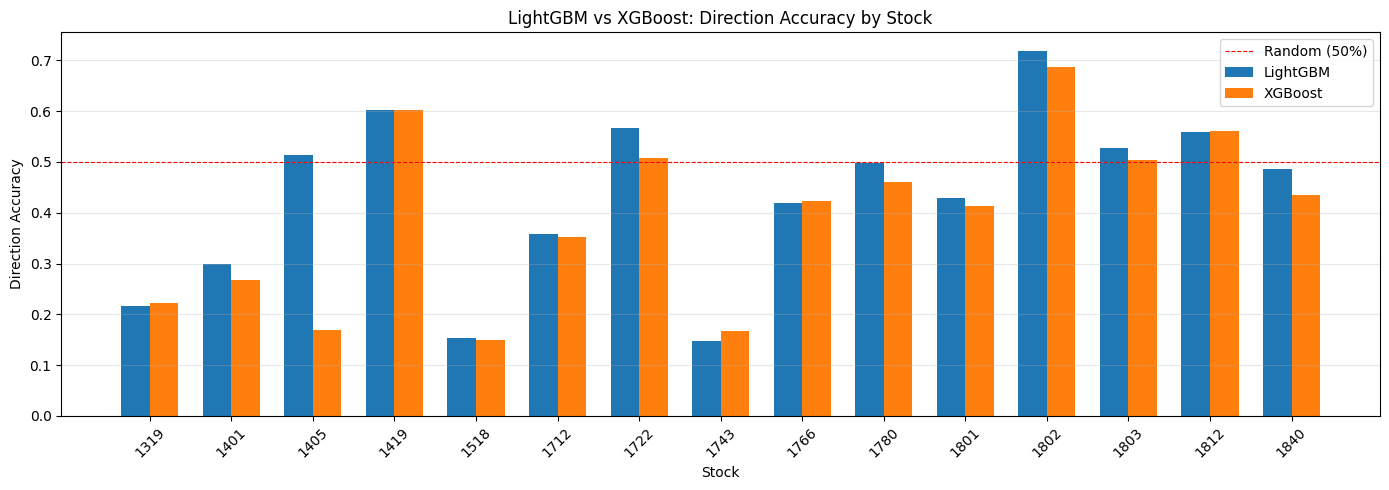

In [7]:
pivot_da = df_res.pivot(index="ticker", columns="model", values="DirAcc")

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(pivot_da))

bars1 = ax.bar(x - width/2, pivot_da["LightGBM"], width, label="LightGBM", color="#1f77b4")
bars2 = ax.bar(x + width/2, pivot_da["XGBoost"], width, label="XGBoost", color="#ff7f0e")

ax.axhline(y=0.5, color="red", linestyle="--", linewidth=0.8, label="Random (50%)")
ax.set_xlabel("Stock")
ax.set_ylabel("Direction Accuracy")
ax.set_title("LightGBM vs XGBoost: Direction Accuracy by Stock")
ax.set_xticks(x)
ax.set_xticklabels(pivot_da.index, rotation=45)
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("lgbm_xgb_diraccc_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. 特征重要性（以 LightGBM 为例）

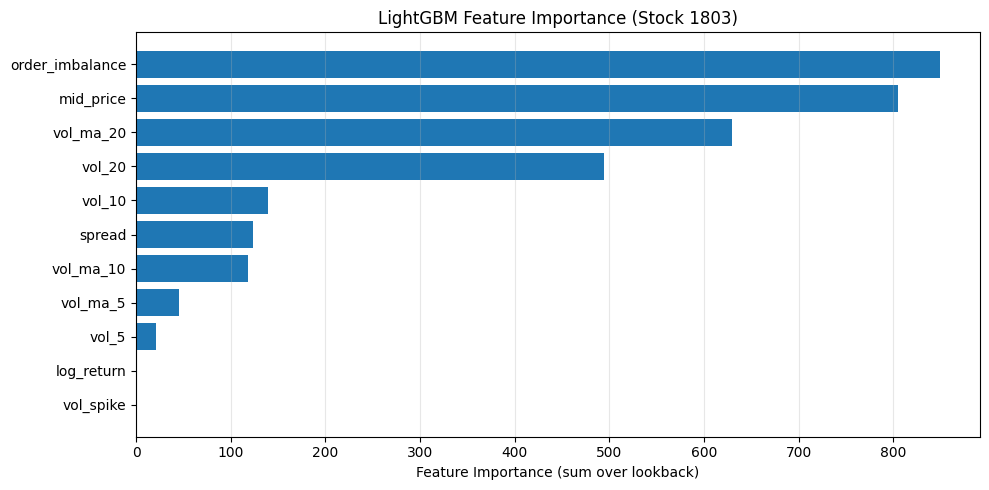

In [8]:
# 用最后一只训练的 LightGBM 模型展示特征重要性
# 特征名 = lookback 步 × 11 个特征 → 生成可读名称
feat_names = []
for t in range(LOOKBACK):
    for f in FEATURE_COLS:
        feat_names.append(f"{f}_t-{LOOKBACK - t}")

importance = lgbm_model.feature_importances_

# 按原始特征名聚合（跨 lookback 步求和）
agg_imp = {}
for name, imp in zip(feat_names, importance):
    base = name.rsplit("_t-", 1)[0]
    agg_imp[base] = agg_imp.get(base, 0) + imp

agg_imp = dict(sorted(agg_imp.items(), key=lambda x: x[1], reverse=True))

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(list(agg_imp.keys())[::-1], list(agg_imp.values())[::-1], color="#1f77b4")
ax.set_xlabel("Feature Importance (sum over lookback)")
ax.set_title(f"LightGBM Feature Importance (Stock {ticker})")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("lgbm_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. 残差分析

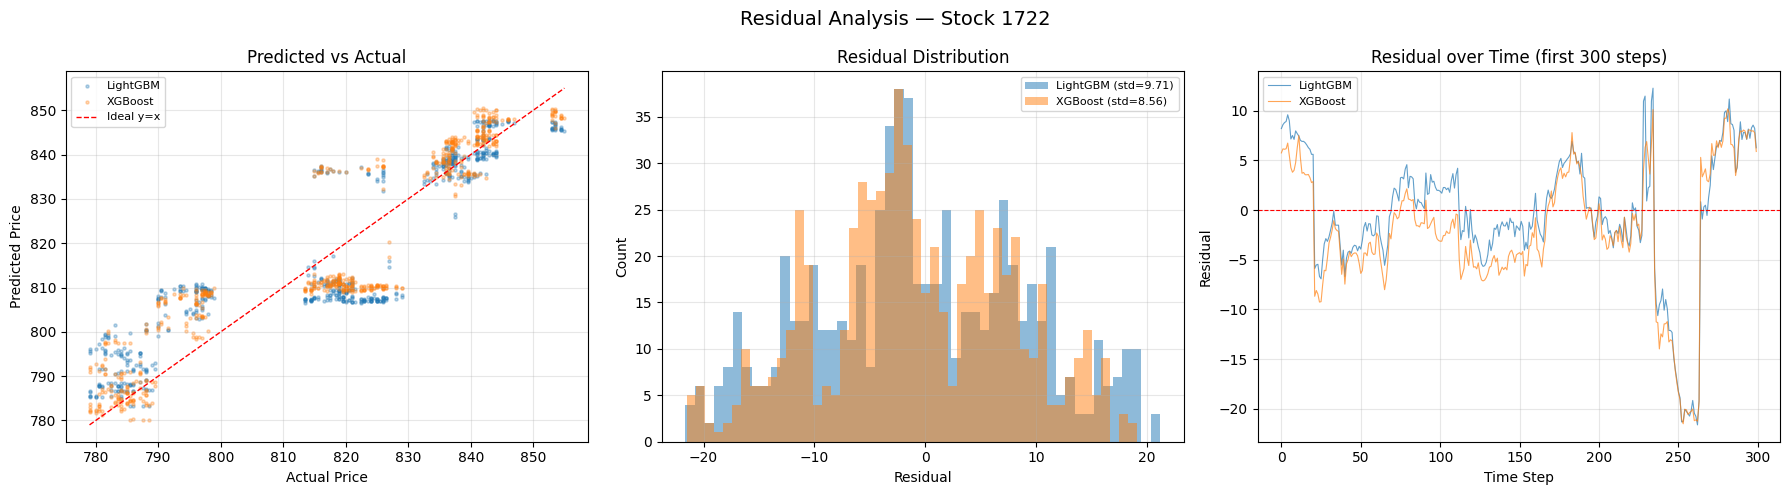

In [9]:
# 用 R² 最高的股票做残差分析
best_ticker = top_tickers[0]
p = best_preds[best_ticker]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"Residual Analysis — Stock {best_ticker}", fontsize=14)

for i, (name, y_pred) in enumerate([("LightGBM", p["lgbm"]), ("XGBoost", p["xgb"])]):
    residuals = p["y_test"] - y_pred

    # 散点图: 预测 vs 真实
    axes[0].scatter(p["y_test"], y_pred, alpha=0.3, s=5, label=name)

    # 残差分布
    axes[1].hist(residuals, bins=50, alpha=0.5, label=f"{name} (std={residuals.std():.2f})")

# 预测 vs 真实 散点
lim = [p["y_test"].min(), p["y_test"].max()]
axes[0].plot(lim, lim, "r--", linewidth=1, label="Ideal y=x")
axes[0].set_xlabel("Actual Price")
axes[0].set_ylabel("Predicted Price")
axes[0].set_title("Predicted vs Actual")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# 残差分布
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual Distribution")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# 残差时序
for name, y_pred in [("LightGBM", p["lgbm"]), ("XGBoost", p["xgb"])]:
    axes[2].plot((p["y_test"] - y_pred)[:300], alpha=0.7, linewidth=0.8, label=name)
axes[2].axhline(0, color="red", linestyle="--", linewidth=0.8)
axes[2].set_xlabel("Time Step")
axes[2].set_ylabel("Residual")
axes[2].set_title("Residual over Time (first 300 steps)")
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("residual_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. 结果保存

In [10]:
df_res.to_csv("baseline_results.csv", index=False)
print("结果已保存为 baselines/baseline_results.csv")
print("\n最终汇总：")
print(summary.to_string())

结果已保存为 baselines/baseline_results.csv

最终汇总：
             RMSE      MAE      R2  DirAcc  train_s  infer_s
model                                                       
LightGBM  24.9981  20.6014  0.0010  0.4330   2.3649   0.0019
XGBoost   25.0242  20.3862 -0.0417  0.3944   1.5117   0.0007
